# Football player roles: conformal prediction sets

**Question:** given a football player's individual skill ratings, which broad role is consistent with those attributes: **Defender, Midfielder, Attacker, or Goalkeeper**?

The dataset has 18,147 distinct players from the FIFA 19 player dataset. Four classifiers produce scores; the library constructs **collapsed, radial, and strip** prediction sets. We judge the result by **coverage and set size together**, keeping the nominal coverage target at **90%**.

<!-- **Run independently:** open this notebook in the repository and run all cells in order. Use a Python 3.10+ kernel with `python -m pip install -e ".[examples]"` installed from the repository.  -->

The first run downloads one approximately 9 MB CSV. Results go into `outputs/football_players/`.

<!-- This notebook reconstructs the dataset's recorded role from video-game skill assessments. 
It is not a forecast of match outcomes, a scouting recommendation, or a test of future real-world performance. The ratings are subjective and may themselves reflect a player's role. This is an informative classification benchmark, with that limitation stated openly. -->

## Imports and fixed settings

The target mapping, features, split fractions, model settings, and `ALPHA = 0.10` are declared before test evaluation. Classifier validation is separated from envelope calibration and the final test. 

In [1]:
import sys
import io
import json
import hashlib
import platform
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter, sleep
from urllib.request import Request, urlopen
from urllib.error import URLError

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from threadpoolctl import threadpool_limits
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, log_loss

In [2]:
LIBRARY_PARENT = None  # e.g. '/path/to/Conformal Library'
if LIBRARY_PARENT is not None:
    ROOT = Path(LIBRARY_PARENT).expanduser().resolve()
else:
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'conformal_envelopes' / '__init__.py').is_file()), None)
if ROOT is None or not (ROOT / 'conformal_envelopes' / '__init__.py').is_file():
    raise FileNotFoundError('Set LIBRARY_PARENT to the folder containing conformal_envelopes/.')
sys.path.insert(0, str(ROOT))

import conformal_envelopes
from conformal_envelopes import ConformalSetModel, evaluate_prediction_sets, plot_inclusion_heatmap

DATA_DIR = ROOT / 'data' / 'football_players'
OUTPUT_DIR = ROOT / 'outputs' / 'football_players'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
SEED = 25
ALPHA = 0.10
SHAPE_FRACTION = 0.5
CLASSES = ['Defender', 'Midfielder', 'Attacker', 'Goalkeeper']
METHOD_PARAMS = {'collapsed': {},
                 'radial': {'n_directions': 100, 'smoothing': 4.0, 'angle_deg': 30.0, 'neighbor_fraction': 0.2},
                 'strip': {'n_bins': 8, 'min_samples': 10},}

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.max_columns', 16)
print('Library:', conformal_envelopes.__file__)

Library: /home/siddiqun/Bureau/Conformal Library/conformal_envelopes/__init__.py


## Dataset source and a reproducible download

The source is [Karan Gadiya's FIFA 19 dataset on Kaggle](https://www.kaggle.com/datasets/karangadiya/fifa19), containing 18,207 player records. To avoid a login requirement, we can download the CSV from a [public GitHub mirror](https://github.com/qualityjacks/Fifa19_Insights) that identifies the Kaggle source. The mirror is a redistribution, not an official EA or SoFIFA download endpoint.

The CSV includes identity fields, a recorded `Position`, individual skill attributes, and many other fields that we deliberately do not use.

In [4]:
SOURCE_URL = 'https://raw.githubusercontent.com/qualityjacks/Fifa19_Insights/334610dd4516e0471db53a47bb195a35c808f926/data.csv'
EXPECTED_SHA256 = 'c56b54025a85cb1f8c85b9745abf4c5b41f1f430c1a52a50b2fa872cb14b6128'
DATA_PATH = DATA_DIR / 'fifa19.csv'
if DATA_PATH.exists():
    payload = DATA_PATH.read_bytes()
else:
    for attempt in range(3):
        try:
            request = Request(SOURCE_URL, headers={'User-Agent': 'FootballConformalExample/1.0'})
            with urlopen(request, timeout=60) as response:
                payload = response.read()
            break
        except (URLError, TimeoutError, OSError) as exc:
            if attempt == 2:
                raise RuntimeError(f'Download failed. Check internet access or save the CSV at {DATA_PATH}.') from exc
            sleep(attempt + 1)
actual_sha256 = hashlib.sha256(payload).hexdigest()
if actual_sha256 != EXPECTED_SHA256:
    raise ValueError('Dataset checksum mismatch: inspect the file instead of silently using changed data.')
raw = pd.read_csv(io.BytesIO(payload))
assert len(raw) == 18207, 'Unexpected source row count.'
assert raw['ID'].notna().all() and raw['ID'].is_unique, 'Player IDs must be present and unique.'
if not DATA_PATH.exists():
    temporary = DATA_PATH.with_suffix('.tmp')
    temporary.write_bytes(payload)
    temporary.replace(DATA_PATH)
manifest = {'source_url': SOURCE_URL, 'sha256': actual_sha256,
            'original_source': 'https://www.kaggle.com/datasets/karangadiya/fifa19',
            'raw_rows': len(raw)}
(OUTPUT_DIR / 'source_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print(f'Loaded {len(raw):,} unique player records from {DATA_PATH.name}.')
display(raw[['ID', 'Name', 'Position', 'Crossing', 'Finishing', 'ShortPassing', 'StandingTackle']].head())

Loaded 18,207 unique player records from fifa19.csv.


,ID,Name,Position,Crossing,Finishing,ShortPassing,StandingTackle
0,158023,L. Messi,RF,84.0,95.0,90.0,28.0
1,20801,Cristiano Ronaldo,ST,84.0,94.0,81.0,31.0
2,190871,Neymar Jr,LW,79.0,87.0,84.0,24.0
3,193080,De Gea,GK,17.0,13.0,50.0,21.0
4,192985,K. De Bruyne,RCM,93.0,82.0,92.0,58.0


## Defining the target

We use a fixed football-role grouping:

| Class | Recorded positions |
|---|---|
| Defender | CB, LCB, RCB, LB, RB, LWB, RWB |
| Midfielder | CDM, LDM, RDM, CM, LCM, RCM, CAM, LAM, RAM, LM, RM |
| Attacker | ST, LS, RS, CF, LF, RF, LW, RW |
| Goalkeeper | GK |

The Wing-backs are grouped with defenders, wide midfielders with midfielders, and wingers with attackers. These boundaries are a declared modeling choice: football roles overlap. We predict this mapping of the **single recorded position**, not every role a player could reasonably play.

Goalkeepers are included as a fourth class. Read the per-class results as well as aggregate coverage, because goalkeepers are easier to distinguish. Records with missing positions are excluded because they have no usable target. Other unexpected position codes cause an error instead of being silently removed. We retain low-rated players and difficult examples; there is no filtering based on model confidence or correctness.

In [5]:
ROLE_GROUPS = {'Defender': ['CB', 'LCB', 'RCB', 'LB', 'RB', 'LWB', 'RWB'],
               'Midfielder': ['CDM', 'LDM', 'RDM', 'CM', 'LCM', 'RCM', 'CAM', 'LAM', 'RAM', 'LM', 'RM'],
               'Attacker': ['ST', 'LS', 'RS', 'CF', 'LF', 'RF', 'LW', 'RW'],
               'Goalkeeper': ['GK'],}

position_to_role = {position: role for role, positions in ROLE_GROUPS.items() for position in positions}
assert len(position_to_role) == sum(map(len, ROLE_GROUPS.values()))
unknown = set(raw['Position'].dropna()) - set(position_to_role)
assert not unknown, f'Unmapped position codes: {unknown}'
missing_position = raw['Position'].isna()
players = raw.loc[~missing_position].copy()
players['label'] = players['Position'].map(position_to_role)
players['ID'] = 'fifa19:' + players['ID'].astype(str)
players = players.reset_index(drop=True)
audit = pd.DataFrame({'stage': ['Original rows', 'Missing position excluded', 'Players retained'],
                       'rows': [len(raw), int(missing_position.sum()), len(players)]})
assert len(players) + missing_position.sum() == len(raw)
assert players['ID'].is_unique and players['label'].notna().all()
display(audit)

,stage,rows
0,Original rows,18207
1,Missing position excluded,60
2,Players retained,18147


In [6]:
display(players['label'].value_counts().reindex(CLASSES).rename('players').to_frame())
audit.to_csv(OUTPUT_DIR / 'cleaning_audit.csv', index=False)

,players
label,
Defender,5866
Midfielder,6838
Attacker,3418
Goalkeeper,2025


## Selecting individual skill attributes and excluding target proxies

The 34 numeric predictors below describe technical and physical skills: passing, finishing, tackling, speed, strength, and related attributes. We explicitly exclude:

- `Position` and the derived `label`;
- positional suitability columns (`ST`, `CB`, `CM`, etc.), which already summarize how well a player fits a position;
- player ID/name, club, nationality, jersey number, overall rating, potential, wages, and transfer value;

We include five goalkeeper skills: diving, handling, kicking, positioning, and reflexes.

The numeric **`Positioning`** attribute means attacking-positioning skill; it is not the categorical `Position` target. It is an individual skill measurement and is retained. Even with direct proxies excluded, FIFA ratings reflect subjective assessments connected to playing roles. 

We checked that all retained skills are finite and between 0 and 100. This version of the player data is complete, so no imputation is needed. If a different source introduces missing skills, preprocessing must be learned on classifier-training data only.

In [7]:
FEATURES = ['Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
            'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
            'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
            'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots',
            'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
            'Composure', 'Marking', 'StandingTackle', 'SlidingTackle',
            'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes']
for column in FEATURES:
    players[column] = pd.to_numeric(players[column], errors='raise')
assert np.isfinite(players[FEATURES]).all().all()
assert players[FEATURES].ge(0).all().all() and players[FEATURES].le(100).all().all()
forbidden = set(position_to_role) | {'Position', 'label', 'ID', 'Name', 'Overall', 'Potential', 'Club'}
assert not set(FEATURES).intersection(forbidden)
print('Number of skill features:', len(FEATURES))
display(players[['ID', 'Name', 'Position', 'label', 'Finishing', 'ShortPassing', 'StandingTackle']].head())

Number of skill features: 34


,ID,Name,Position,label,Finishing,ShortPassing,StandingTackle
0,fifa19:158023,L. Messi,RF,Attacker,95.0,90.0,28.0
1,fifa19:20801,Cristiano Ronaldo,ST,Attacker,94.0,81.0,31.0
2,fifa19:190871,Neymar Jr,LW,Attacker,87.0,84.0,24.0
3,fifa19:193080,De Gea,GK,Goalkeeper,13.0,50.0,21.0
4,fifa19:192985,K. De Bruyne,RCM,Midfielder,82.0,92.0,58.0


## Four disjoint data roles

| Partition | Fraction | Allowed use |
|---|---:|---|
| `base_train` | 40% | Fit classifiers and their scalers |
| `validation_players` | 20% | Check whether classifier scores are informative, before final evaluation |
| `conformal_train` | 30% | Fit envelope shape and calibration using frozen classifiers |
| `test_players` | 10% | Evaluate the finished procedure once |

Splits are stratified by the four role labels with fixed seeds. Every player appears in one partition only. A single FIFA edition prevents the same player in different years from leaking across splits. The library further splits each role's `conformal_train` rows approximately 50/50 into S1 and S2.

In [8]:
development, test_players = train_test_split(players, test_size=0.10,
    stratify=players['label'], random_state=SEED)
development, conformal_train = train_test_split(development, test_size=0.30 / 0.90,
    stratify=development['label'], random_state=SEED + 1)
base_train, validation_players = train_test_split(development, test_size=1/3,
    stratify=development['label'], random_state=SEED + 2)
partitions = {'classifier training': base_train, 'validation': validation_players,
              'conformal fitting': conformal_train, 'final test': test_players}
id_sets = [set(frame['ID']) for frame in partitions.values()]
assert all(id_sets[i].isdisjoint(id_sets[j]) for i in range(4) for j in range(i+1, 4))
assert set.union(*id_sets) == set(players['ID'])
split_counts = pd.DataFrame({name: frame['label'].value_counts().reindex(CLASSES)
                             for name, frame in partitions.items()}).T
split_counts['total'] = split_counts.sum(axis=1)
display(split_counts)
split_counts.to_csv(OUTPUT_DIR / 'partition_counts.csv')
partition_ids = pd.concat([frame[['ID', 'label']].assign(partition=name) for name, frame in partitions.items()])
partition_ids.to_csv(OUTPUT_DIR / 'partition_ids.csv', index=False)

label,Defender,Midfielder,Attacker,Goalkeeper,total
classifier training,2346,2735,1367,810,7258
validation,1173,1368,684,405,3630
conformal fitting,1760,2051,1025,608,5444
final test,587,684,342,202,1815


## Inspecting the classifier-training players only

The boxplots are raw FIFA skill ratings, not probabilities or nonconformity coordinates. There is still overlap: a midfielder can tackle well, and an attacker can pass well. A prediction set containing two roles can represent that ambiguity.

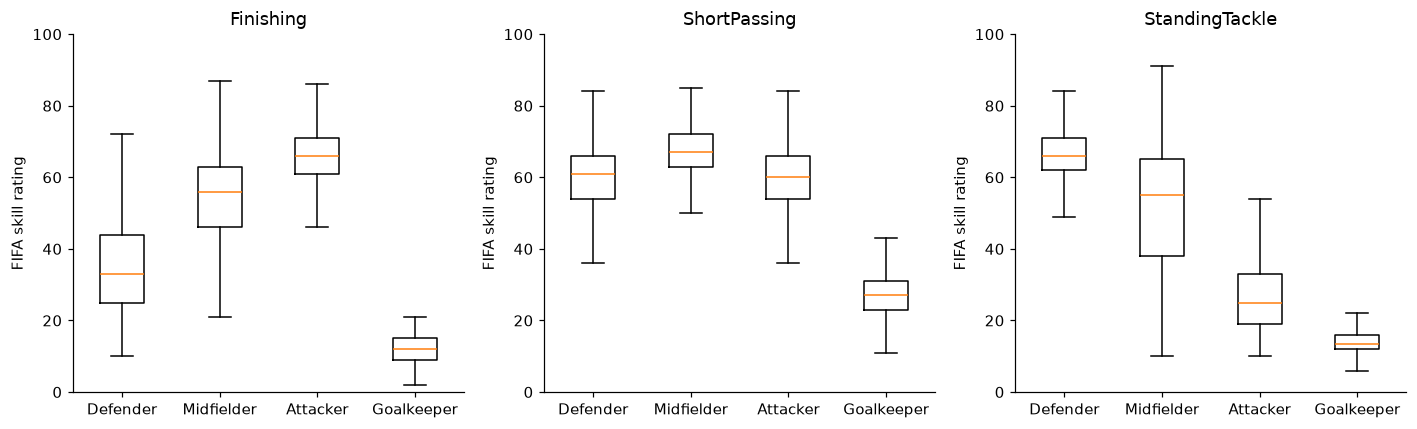

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, feature in zip(axes, ['Finishing', 'ShortPassing', 'StandingTackle']):
    ax.boxplot([base_train.loc[base_train['label'].eq(role), feature] for role in CLASSES],
               tick_labels=CLASSES, showfliers=False)
    ax.set(title=feature, ylabel='FIFA skill rating', ylim=(0, 100))
plt.tight_layout()
plt.show()

## Fitting four different classifiers

| Predictor | Model | Why it is included |
|---|---|---|
| `logreg` | Standardized logistic regression | A transparent linear baseline in skill space |
| `forest` | Random forest, 250 trees, minimum leaf size 3 | Nonlinear combinations of skills |
| `boost` | Histogram gradient boosting, 200 iterations | A second nonlinear score construction |
| `svc` | Standardized RBF support-vector classifier | Smooth nonlinear boundaries with probability estimates |

These fixed settings were not selected on the test players. The scaler in the logistic pipeline is learned from `base_train` only. Boosting's automatic early stopping is not triggered at this training size; all 200 iterations run. The four predictors share features, so their errors are not independent. We use two threads to keep resource use predictable.

The SVC uses `CalibratedClassifierCV` with five-fold sigmoid probability calibration inside classifier-training data only. Each fold fits its own scaler; the final classifier is fitted on the full classifier-training partition. This probability calibration is separate from the library's conformal S2 calibration. The new classifier is included as another score source, not selected using test performance.

In [10]:
classifiers = {'logreg': make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=2000, random_state=SEED)),
               'forest': RandomForestClassifier(n_estimators=250, min_samples_leaf=3, max_features='sqrt',
                                                n_jobs=1, random_state=SEED),
               'boost': HistGradientBoostingClassifier(max_iter=200, max_leaf_nodes=15, learning_rate=0.08,
                                                       l2_regularization=1.0, random_state=SEED),
               'svc': CalibratedClassifierCV(
                   make_pipeline(StandardScaler(), SVC(C=3.0, kernel='rbf', random_state=SEED)),
                   method='sigmoid', cv=5, ensemble=False),}
classifier_fit_seconds = {}
with threadpool_limits(limits=2):
    for name, classifier in classifiers.items():
        start = perf_counter()
        classifier.fit(base_train[FEATURES], base_train['label'])
        classifier_fit_seconds[name] = perf_counter() - start
        assert set(classifier.classes_) == set(CLASSES)
        print(f'{name}: fitted on {len(base_train):,} players in {classifier_fit_seconds[name]:.2f}s')

logreg: fitted on 7,258 players in 0.14s


forest: fitted on 7,258 players in 2.52s


boost: fitted on 7,258 players in 1.00s


svc: fitted on 7,258 players in 2.94s


### Validation: is there useful class information?

Before envelope fitting, evaluate the fixed classifiers on validation players. Accuracy measures the best single-role prediction; log loss assesses the full probability vector, with lower values better. Neither is conformal coverage. We also show each role's recall so an easy majority class cannot conceal a poor minority result.

In [11]:
validation_rows, validation_class_rows = [], []
with threadpool_limits(limits=2):
    for name, classifier in classifiers.items():
        probabilities = classifier.predict_proba(validation_players[FEATURES])
        chosen = classifier.classes_[probabilities.argmax(axis=1)]
        validation_rows.append({'predictor': name,
            'accuracy': accuracy_score(validation_players['label'], chosen),
            'log_loss': log_loss(validation_players['label'], probabilities, labels=classifier.classes_)})
        for role in CLASSES:
            mask = validation_players['label'].eq(role).to_numpy()
            validation_class_rows.append({'predictor': name, 'role': role, 'n_validation': int(mask.sum()),
                                          'recall': (chosen[mask] == role).mean()})
validation_summary = pd.DataFrame(validation_rows).set_index('predictor')
display(validation_summary.round(4))

,accuracy,log_loss
predictor,,
logreg,0.8771,0.3037
forest,0.8782,0.3215
boost,0.8741,0.3163
svc,0.8837,0.3276


In [12]:
display(pd.DataFrame(validation_class_rows).round(4))
validation_summary.to_csv(OUTPUT_DIR / 'validation_metrics.csv')

,predictor,role,n_validation,recall
0,logreg,Defender,1173,0.9250
1,logreg,Midfielder,1368,0.8560
2,logreg,Attacker,684,0.7646
3,logreg,Goalkeeper,405,1.0000
4,forest,Defender,1173,0.9429
5,forest,Midfielder,1368,0.8589
6,forest,Attacker,684,0.7339
7,forest,Goalkeeper,405,1.0000
8,boost,Defender,1173,0.9395
9,boost,Midfielder,1368,0.8509


## Convert skills into the library's score-table format

Raw skill measurements do not go directly into the envelope library. The classifiers turn them into sixteen probabilities: **4 candidate roles × 4 predictors**. `Attacker_forest`, for example, is the forest's estimated probability of the candidate Attacker.

`label_to_columns` assigns exactly four scores to each candidate. On fitting Defender's envelope, the library uses Defender-labeled rows and Defender's four columns. On prediction, every player's Defender scores are tested against that region, and the same is done for Midfielder, Attacker, and Goalkeeper.

We read `classifier.classes_` when assigning columns; alphabetical probability-column order must not be confused with our display order. Test truth is kept separately and aligned by unique ID.

In [13]:
PREDICTORS = list(classifiers)
label_to_columns = {label: [f'{label}_{name}' for name in PREDICTORS] for label in CLASSES}
score_cols = [column for label in CLASSES for column in label_to_columns[label]]

def make_score_frame(frame):
    scores = pd.DataFrame({'ID': frame['ID'].to_numpy()})
    for name, classifier in classifiers.items():
        probabilities = classifier.predict_proba(frame[FEATURES])
        assert np.isfinite(probabilities).all()
        assert np.allclose(probabilities.sum(axis=1), 1)
        for j, label in enumerate(classifier.classes_):
            scores[f'{label}_{name}'] = probabilities[:, j]
    scores = scores[['ID', *score_cols]]
    assert scores['ID'].is_unique
    assert scores[score_cols].ge(0).all().all() and scores[score_cols].le(1).all().all()
    return scores

conformal_scores = make_score_frame(conformal_train)
conformal_scores['label'] = conformal_train['label'].to_numpy()
test_scores = make_score_frame(test_players)
test_truth = test_players.set_index('ID')['label']
assert 'label' not in test_scores.columns
assert conformal_scores[score_cols].notna().all().all()
assert test_scores[score_cols].notna().all().all()
display(pd.DataFrame(label_to_columns).rename_axis('predictor position'))

,Defender,Midfielder,Attacker,Goalkeeper
predictor position,,,,
0,Defender_logreg,Midfielder_logreg,Attacker_logreg,Goalkeeper_logreg
1,Defender_forest,Midfielder_forest,Attacker_forest,Goalkeeper_forest
2,Defender_boost,Midfielder_boost,Attacker_boost,Goalkeeper_boost
3,Defender_svc,Midfielder_svc,Attacker_svc,Goalkeeper_svc


In [14]:
display(conformal_scores.head().round(4))
print('Conformal table:', conformal_scores.shape, '| Test table:', test_scores.shape)

,ID,Defender_logreg,Defender_forest,Defender_boost,Defender_svc,Midfielder_logreg,Midfielder_forest,Midfielder_boost,...,Attacker_forest,Attacker_boost,Attacker_svc,Goalkeeper_logreg,Goalkeeper_forest,Goalkeeper_boost,Goalkeeper_svc,label
0,fifa19:216255,0.0001,0.0000,0.0011,0.0002,0.8156,0.8381,0.8790,...,0.1619,0.1198,0.2192,0.0000,0.0,0.0000,0.0001,Attacker
1,fifa19:214350,0.0000,0.0038,0.0000,0.0002,0.0356,0.0482,0.0014,...,0.9480,0.9986,0.8997,0.0000,0.0,0.0000,0.0002,Attacker
2,fifa19:178088,0.0000,0.0000,0.0001,0.0002,0.8097,0.5591,0.6115,...,0.4409,0.3883,0.2142,0.0000,0.0,0.0000,0.0002,Midfielder
3,fifa19:244725,0.3382,0.1789,0.0145,0.1335,0.6601,0.8143,0.9850,...,0.0068,0.0005,0.0036,0.0001,0.0,0.0000,0.0002,Midfielder
4,fifa19:163201,0.0000,0.0000,0.0000,0.0306,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0002,1.0000,1.0,0.9999,0.9685,Goalkeeper


Conformal table: (5444, 18) | Test table: (1815, 17)


## Following one player from skills to scores

High probability supports a candidate. The library converts each coordinate $p$ to $1-p$, so low nonconformity supports the candidate. 

These coordinates are not yet the method's combined calibration statistic.

In [15]:
example = conformal_scores.iloc[0]
player_info = conformal_train.set_index('ID').loc[example['ID']]
print(player_info['Name'], '| recorded position:', player_info['Position'], '| target role:', example['label'])
score_view = pd.DataFrame({name: [example[f'{role}_{name}'] for role in CLASSES] for name in PREDICTORS},
                          index=pd.Index(CLASSES, name='candidate role'))
print('Probabilities:')
display(score_view.round(4))

M. Stefaniak | recorded position: LW | target role: Attacker
Probabilities:


,logreg,forest,boost,svc
candidate role,,,,
Defender,0.0001,0.0000,0.0011,0.0002
Midfielder,0.8156,0.8381,0.8790,0.7805
Attacker,0.1843,0.1619,0.1198,0.2192
Goalkeeper,0.0000,0.0000,0.0000,0.0001


In [16]:
print('Coordinate-wise nonconformity:')
display((1 - score_view).round(4))

Coordinate-wise nonconformity:


,logreg,forest,boost,svc
candidate role,,,,
Defender,0.9999,1.0000,0.9989,0.9998
Midfielder,0.1844,0.1619,0.1210,0.2195
Attacker,0.8157,0.8381,0.8802,0.7808
Goalkeeper,1.0000,1.0000,1.0000,0.9999


--
## Fitting the three conformal envelope methods

- **Collapsed:** averages the candidate's observed nonconformity coordinates.
- **Radial:** learns a direction-dependent boundary in score space.
- **Strip:** learns constraints involving pairs of score coordinates.

S1 learns the shape; S2 calibrates a threshold. The classwise finite-sample order is $k=\lceil(n_{S2}+1)(1-\alpha)\rceil$. 
Larger S2 gives finer rank resolution, not automatic predictive information. At `alpha=0.10`, the nominal target remains 90%.

In [17]:
models, fit_times = {}, {}
for method, params in METHOD_PARAMS.items():
    model = ConformalSetModel(method=method, alpha=ALPHA, random_state=SEED,
                              score_direction='higher_is_better', shape_fraction=SHAPE_FRACTION,
                              force_nonempty=False, **params)
    start = perf_counter()
    model.fit(conformal_scores, id_col='ID', label_col='label', score_cols=score_cols,
              label_to_columns=label_to_columns)
    fit_times[method] = perf_counter() - start
    models[method] = model
    print(f'{method}: fitted in {fit_times[method]:.2f}s')

collapsed: fitted in 0.01s
radial: fitted in 0.16s


strip: fitted in 0.07s


### Verifying the actual calibration counts

`t_hat` is a geometric scaling threshold, not coverage or a probability. Its numerical scale differs across methods.

In [18]:
envelope_rows = []
for method, model in models.items():
    for label, info in model.get_envelopes().items():
        n_cal = info['calibration_size']
        envelope_rows.append({'method': method, 'class': label, 'shape_n': info['shape_size'],
            'calibration_n': n_cal, 'rank_step': 1 / (n_cal + 1), 
            'quantile_rank': int(np.ceil((n_cal + 1) * (1 - ALPHA))),
            't_hat': info['envelope']['t_hat']})
envelope_summary = pd.DataFrame(envelope_rows)
assert envelope_summary['calibration_n'].min() >= 200
assert np.isfinite(envelope_summary['t_hat']).all(), 'Investigate an infinite threshold.'
display(envelope_summary.round(5))
envelope_summary.to_csv(OUTPUT_DIR / 'envelope_summary.csv', index=False)

,method,class,shape_n,calibration_n,rank_step,quantile_rank,t_hat
0,collapsed,Attacker,512,513,0.00195,463,1.00117
1,collapsed,Defender,880,880,0.00114,793,0.79251
2,collapsed,Goalkeeper,304,304,0.00328,275,0.99011
3,collapsed,Midfielder,1025,1026,0.00097,925,0.92645
4,radial,Attacker,512,513,0.00195,463,1.04749
5,radial,Defender,880,880,0.00114,793,0.64721
6,radial,Goalkeeper,304,304,0.00328,275,1.02595
7,radial,Midfielder,1025,1026,0.00097,925,1.00808
8,strip,Attacker,512,513,0.00195,463,0.89907
9,strip,Defender,880,880,0.00114,793,0.54248


## Predicting sets 
Each player receives the roles whose envelopes accept that player's score vector. A singleton is one accepted role, a two-role set expresses ambiguity, a full set accepts all four roles, and an empty set accepts none. **Smaller is useful only if coverage remains adequate.** We evaluate every retained test player, including ambiguous cases.

In [19]:
predictions, predict_times = {}, {}
for method, model in models.items():
    start = perf_counter()
    result = model.predict(test_scores)
    predict_times[method] = perf_counter() - start
    assert result['ID'].is_unique and set(result['ID']) == set(test_scores['ID'])
    assert (result['set_size'] == result['prediction_set'].map(len)).all()
    assert result['prediction_set'].map(lambda s: set(s).issubset(CLASSES)).all()
    assert not result['forced'].any()
    predictions[method] = result
SELECTED_METHOD = 'strip'  # For inspection only; not chosen by test performance.
display(predictions[SELECTED_METHOD][['ID', 'prediction_set', 'set_size']].head(12))

,ID,prediction_set,set_size
0,fifa19:178487,[Midfielder],1
1,fifa19:231044,[Midfielder],1
2,fifa19:211398,[Goalkeeper],1
3,fifa19:244621,[Attacker],1
4,fifa19:227998,[Attacker],1
5,fifa19:186961,[Attacker],1
6,fifa19:152991,[Midfielder],1
7,fifa19:210026,[Defender],1
8,fifa19:211127,"[Attacker, Midfielder]",2
9,fifa19:212253,[Midfielder],1


### Independent check of the collapsed acceptance rule

To check score ordering and threshold application, we reconstruct the collapsed decision using only that model's stored S2 indices. For each role, take the finite-sample quantile of the mean `1 - probability` on its true-role S2 rows, then compare every test player's corresponding score with that threshold.

This is a diagnostic, not another method used to generate our results. It should exactly match the library's decisions on this dataset. It does not independently validate the radial or strip geometry.

In [20]:
manual_checks = []
for role, info in models['collapsed'].get_envelopes().items():
    columns = label_to_columns[role]
    true_role_scores = conformal_scores.loc[conformal_scores['label'].eq(role), columns].to_numpy()
    s2_means = (1 - true_role_scores[info['idx_s2']]).mean(axis=1)
    rank = int(np.ceil((len(s2_means) + 1) * (1 - ALPHA)))
    threshold = np.sort(s2_means)[rank - 1] if rank <= len(s2_means) else np.inf
    manual_membership = (1 - test_scores[columns].to_numpy()).mean(axis=1) <= threshold
    library_membership = predictions['collapsed']['prediction_set'].map(lambda labels: role in labels).to_numpy()
    assert np.array_equal(manual_membership, library_membership), f'Membership mismatch for {role}'
    manual_checks.append({'role': role, 'S2_n': len(s2_means), 'rank': rank,
                          'threshold_in_mean_nonconformity': threshold,
                          'matching_decisions': len(manual_membership)})
display(pd.DataFrame(manual_checks))

,role,S2_n,rank,threshold_in_mean_nonconformity,matching_decisions
0,Attacker,513,463,0.781926,1815
1,Defender,880,793,0.285073,1815
2,Goalkeeper,304,275,0.010858,1815
3,Midfielder,1026,925,0.583580,1815


## Evaluating the coverage and efficiency together

| Metric | Meaning |
|---|---|
| Coverage | Fraction of players whose set includes their recorded role |
| Average set size | Mean accepted roles, out of four |
| Singleton rate | Fraction receiving exactly one role |
| Singleton accuracy | Accuracy among singleton sets; undefined if there are none |
| Empty rate | Fraction receiving no role; these are all uncovered |

In [21]:
summary_rows, class_rows = [], []
for method, result in predictions.items():
    truth = test_truth.loc[result['ID']].to_numpy()
    covered = np.array([y in labels for y, labels in zip(truth, result['prediction_set'])])
    metrics = evaluate_prediction_sets(result['prediction_set'], truth.tolist())
    assert np.isclose(metrics['coverage'], covered.mean())
    summary_rows.append({'method': method, **{k: v for k, v in metrics.items() if k != 'per_class_coverage'},
                         'n_test': len(result), 'n_covered': int(covered.sum()),
                         'fit_seconds': fit_times[method], 'predict_seconds': predict_times[method]})
    for label in CLASSES:
        mask = truth == label
        class_rows.append({'method': method, 'class': label, 'n_test': int(mask.sum()),
                           'n_covered': int(covered[mask].sum()), 'coverage': covered[mask].mean(),
                           'average_set_size': result.loc[mask, 'set_size'].mean()})
summary = pd.DataFrame(summary_rows).set_index('method')
class_summary = pd.DataFrame(class_rows)
display(summary.round(4))

,coverage,average_set_size,singleton_rate,singleton_accuracy,empty_rate,n_test,n_covered,fit_seconds,predict_seconds
method,,,,,,,,,
collapsed,0.8904,1.0419,0.8909,0.9153,0.0336,1815,1616,0.0097,0.1022
radial,0.8898,1.0474,0.8887,0.9126,0.0320,1815,1615,0.1568,0.3684
strip,0.8898,1.0579,0.8694,0.9157,0.0364,1815,1615,0.0676,0.1155


In [22]:
display(class_summary.round(4))
summary.to_csv(OUTPUT_DIR / 'metrics.csv')
class_summary.to_csv(OUTPUT_DIR / 'class_metrics.csv', index=False)

,method,class,n_test,n_covered,coverage,average_set_size
0,collapsed,Defender,587,517,0.8807,0.9625
1,collapsed,Midfielder,684,616,0.9006,1.0980
2,collapsed,Attacker,342,303,0.8860,1.1550
3,collapsed,Goalkeeper,202,180,0.8911,0.8911
4,radial,Defender,587,514,0.8756,0.9642
5,radial,Midfielder,684,618,0.9035,1.1023
6,radial,Attacker,342,304,0.8889,1.1754
7,radial,Goalkeeper,202,179,0.8861,0.8861
8,strip,Defender,587,516,0.8790,0.9523
9,strip,Midfielder,684,615,0.8991,1.1287


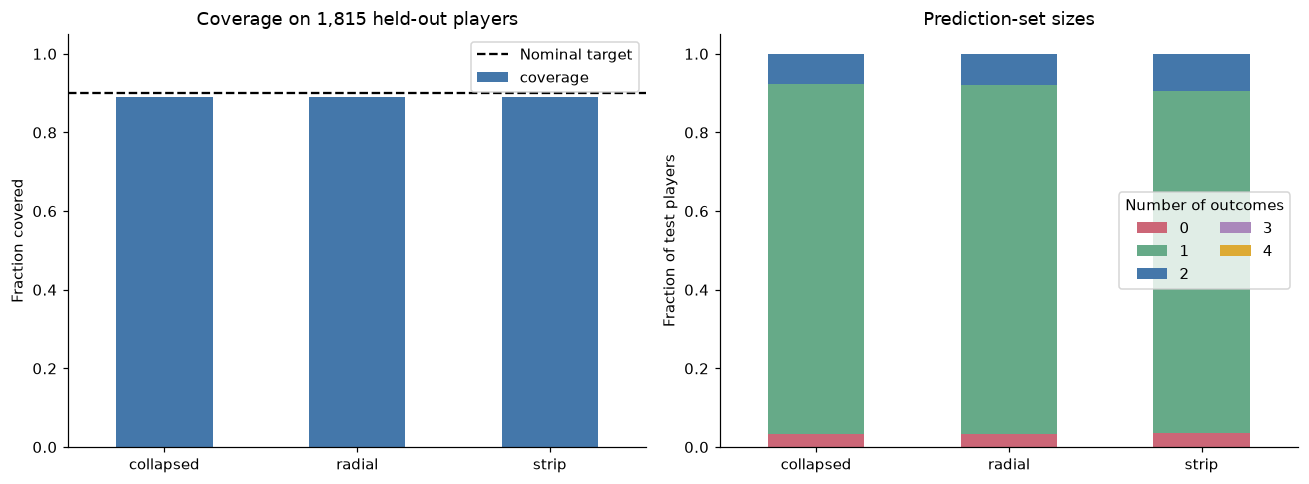

In [23]:
size_counts = pd.DataFrame({method: result['set_size'].value_counts().reindex(range(len(CLASSES) + 1), fill_value=0)
                            for method, result in predictions.items()}).T
size_counts.columns.name = 'set size'
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
summary['coverage'].plot.bar(ax=axes[0], rot=0, color='#4477aa')
axes[0].axhline(1 - ALPHA, color='black', linestyle='--', label='Nominal target')
axes[0].set(ylim=(0, 1.05), xlabel='', ylabel='Fraction covered', title=f'Coverage on {len(test_scores):,} held-out players')
axes[0].legend()
(size_counts / len(test_scores)).plot.bar(stacked=True, ax=axes[1], rot=0,
                                         color=['#cc6677', '#66aa88', '#4477aa', '#aa88bb', '#ddaa33'])
axes[1].set(ylim=(0, 1.05), xlabel='', ylabel='Fraction of test players', title='Prediction-set sizes')
axes[1].legend(title='Number of outcomes', ncol=2)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'coverage_and_set_sizes.png', bbox_inches='tight')
plt.show()

## Inspecting ambiguity without hiding difficult players

We retain names and original positions for interpreting results, but neither was a predictor. A Midfielder/Attacker set may be understandable for an attacking midfielder or winger. Still, measured coverage uses the declared single-role mapping; plausible alternatives do not turn an uncovered prediction into a covered one.

The second table intentionally selects non-singleton or uncovered cases for discussion. It is not a representative performance sample. Grouping coverage by the original position can reveal difficulty hidden by the three broad labels; small subgroup denominators require care.

In [24]:
metadata = test_players.set_index('ID')[['Name', 'Position']]
evaluated = {}
for method, result in predictions.items():
    table = result.set_index('ID').join(metadata, validate='one_to_one')
    table['truth'] = test_truth.reindex(table.index)
    table['covered'] = [role in labels for role, labels in zip(table['truth'], table['prediction_set'])]
    evaluated[method] = table
inspection = evaluated[SELECTED_METHOD][['Name', 'Position', 'truth', 'prediction_set', 'set_size', 'covered']]
display(inspection.head(10))
display(inspection.loc[inspection['set_size'].ne(1) | ~inspection['covered']].head(15))

,Name,Position,truth,prediction_set,set_size,covered
ID,,,,,,
fifa19:178487,C. Gardner,CM,Midfielder,[Midfielder],1,True
fifa19:231044,J. Aribo,LCM,Midfielder,[Midfielder],1,True
fifa19:211398,M. Caillard,GK,Goalkeeper,[Goalkeeper],1,True
fifa19:244621,Vinícius,ST,Attacker,[Attacker],1,True
fifa19:227998,D. Badji,ST,Attacker,[Attacker],1,True
fifa19:186961,A. Paloschi,ST,Attacker,[Attacker],1,True
fifa19:152991,D. Marney,CM,Midfielder,[Midfielder],1,True
fifa19:210026,C. Calvo,CB,Defender,[Defender],1,True
fifa19:211127,M. Håkansson,LM,Midfielder,"[Attacker, Midfielder]",2,True


,Name,Position,truth,prediction_set,set_size,covered
ID,,,,,,
fifa19:211127,M. Håkansson,LM,Midfielder,"[Attacker, Midfielder]",2,True
fifa19:212253,A. Scholz,CB,Defender,[Midfielder],1,False
fifa19:224798,R. Gall,CAM,Midfielder,"[Attacker, Midfielder]",2,True
fifa19:177521,B. Nehrig,CDM,Midfielder,[Defender],1,False
fifa19:216260,F. Kaufmann,RM,Midfielder,[],0,False
fifa19:192342,E. Cardona,LW,Attacker,[Midfielder],1,False
fifa19:53630,J. Van Damme,LCB,Defender,[],0,False
fifa19:228058,L. Gugganig,RDM,Midfielder,[Defender],1,False
fifa19:202535,T. Röcher,LM,Midfielder,"[Attacker, Midfielder]",2,True


In [25]:
position_summary = evaluated[SELECTED_METHOD].groupby('Position').agg(
    n_test=('covered', 'size'), coverage=('covered', 'mean'), average_set_size=('set_size', 'mean'))
display(position_summary.sort_values('n_test', ascending=False).round(4))
position_summary.to_csv(OUTPUT_DIR / 'original_position_metrics.csv')

,n_test,coverage,average_set_size
Position,,,
ST,219,0.9680,1.1142
GK,202,0.8960,0.8960
CB,166,0.8614,0.9518
CM,149,0.9799,1.0000
RB,141,0.9078,0.9504
LB,123,0.8780,0.9512
LM,107,0.8037,1.3645
CAM,102,0.9804,1.2157
RM,98,0.7959,1.3061


## Plotting acceptance regions in classifier-score space

The selected candidate and predictor axes below can be changed freely. `hidden_value = 0.5` is a valid fixed **nonconformity** coordinate for the hidden logistic predictor, not a calibration threshold. It affects only the displayed cross-section, not the fitted model or its predictions.

`plot_slice` displays the existing four-score envelope; test-point categories use each player's actual full score vector. `plot` fits a separate two-score diagnostic envelope. Its categories refer to that separate fit. The evaluation above always uses all four scores and all test players.

Two predictors are now hidden in the slice. Logistic nonconformity retains your chosen 0.5 value; SVC nonconformity is fixed at its median among true-class conformal-fitting players. Both fixed values are shown on the plot.

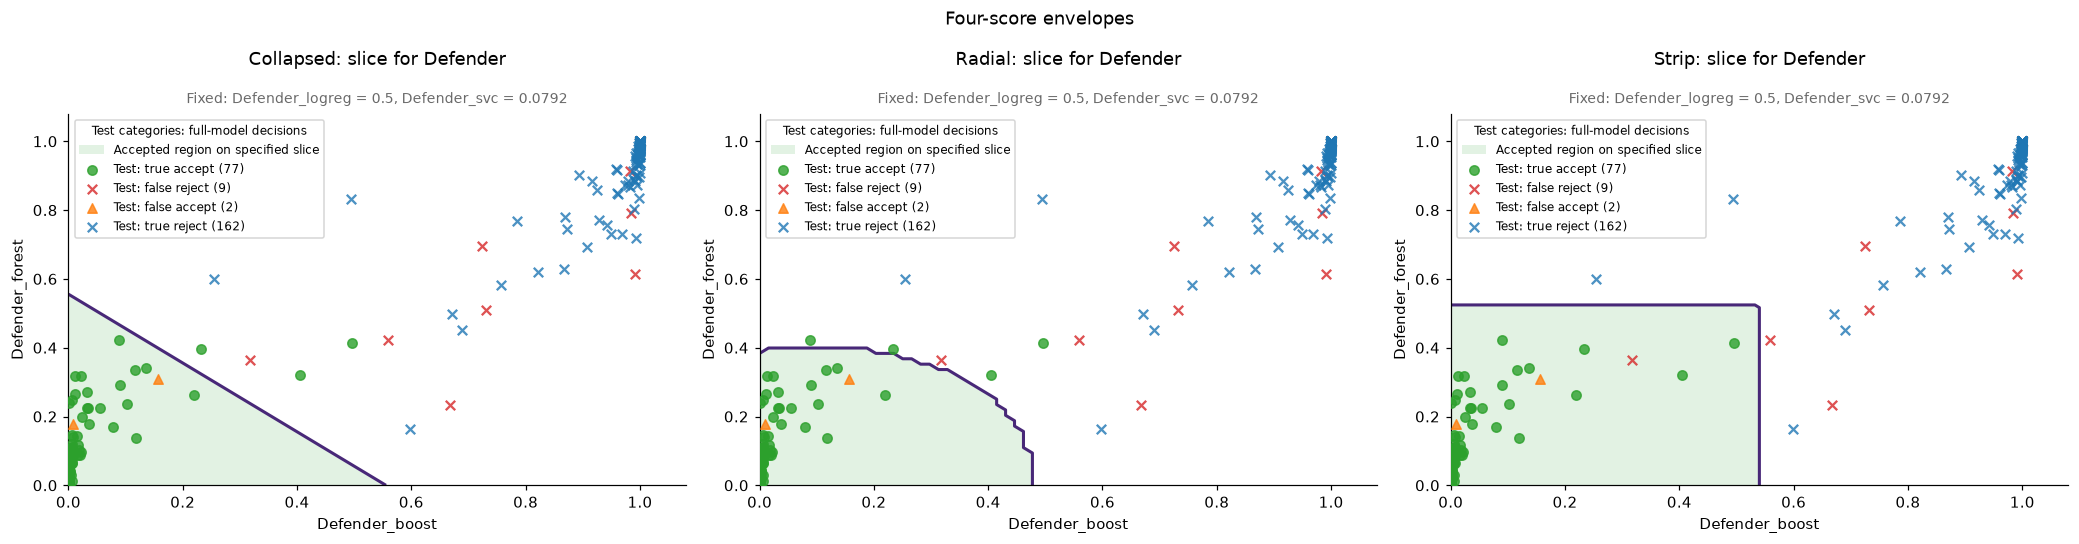

In [26]:
PLOT_LABEL = 'Defender'   # "Defender", "Midfielder", "Attacker", or "Goalkeeper"
x, y = f'{PLOT_LABEL}_boost', f'{PLOT_LABEL}_forest'
hidden = f'{PLOT_LABEL}_logreg'
# hidden_value = float((1 - conformal_scores.loc[conformal_scores['label'].eq(PLOT_LABEL), hidden]).median())
hidden_value = 0.5
svc_hidden = f'{PLOT_LABEL}_svc'
svc_hidden_value = float((1 - conformal_scores.loc[conformal_scores['label'].eq(PLOT_LABEL), svc_hidden]).median())
plot_test = test_scores.sample(n=min(250, len(test_scores)), random_state=SEED).copy()
plot_test['label'] = test_truth.loc[plot_test['ID']].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (method, model) in zip(axes, models.items()):
    model.plot_slice(x=x, y=y, label=PLOT_LABEL, test_data=plot_test,
                     slice_values={hidden: hidden_value, svc_hidden: svc_hidden_value}, grid_size=70, show_training=False,
                     ax=ax, )
    fig.suptitle('Four-score envelopes')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'envelope_slices.png', bbox_inches='tight')
plt.show()

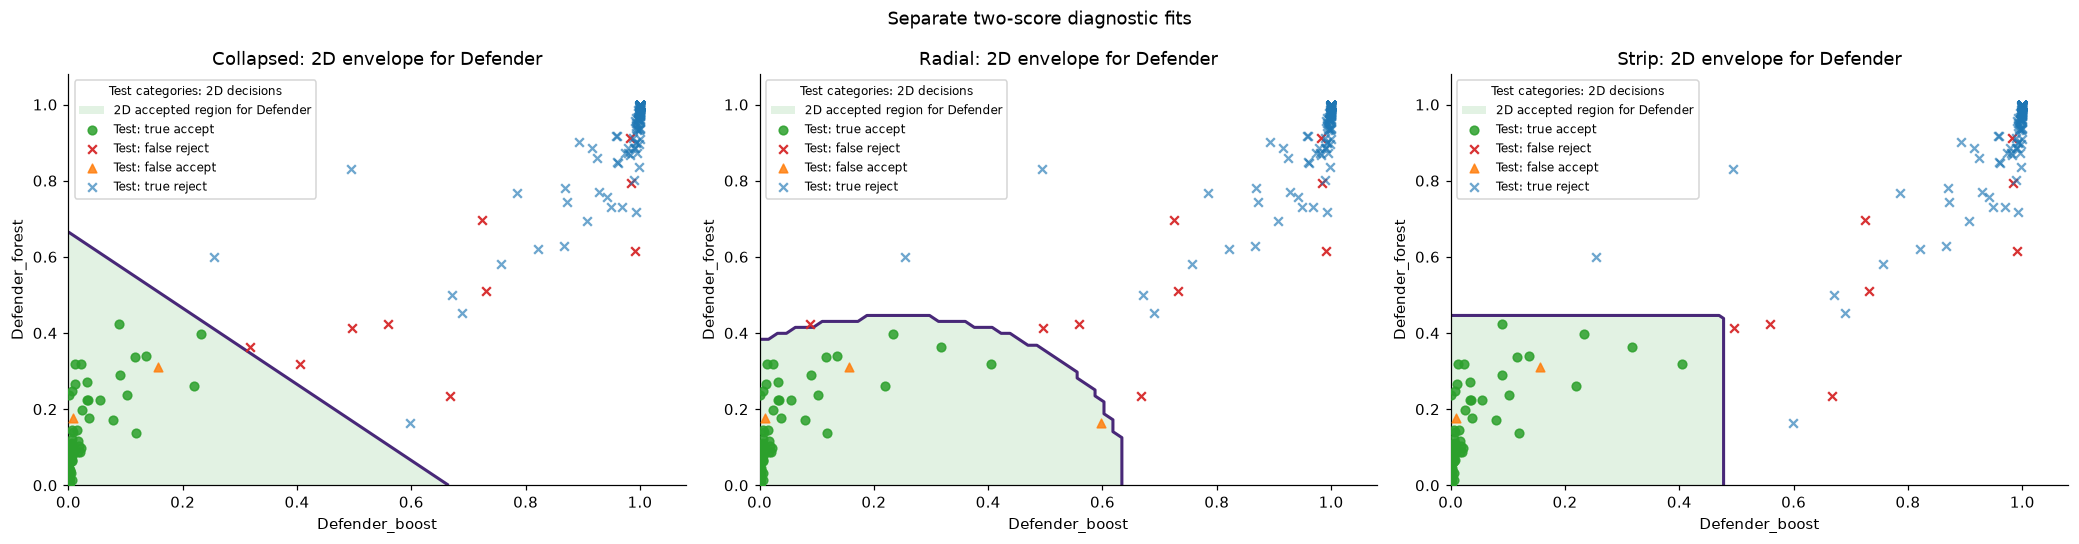

Plotting left all main-model predictions unchanged.


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (method, model) in zip(axes, models.items()):
    model.plot(x=x, y=y, label=PLOT_LABEL, test_data=plot_test,
               grid_size=70, show_training=False, show_other_classes=False, ax=ax)
fig.suptitle('Separate two-score diagnostic fits')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'two_dimensional_diagnostics.png', bbox_inches='tight')
plt.show()
for method, model in models.items():
    pd.testing.assert_frame_equal(model.predict(test_scores), predictions[method])
print('Plotting left all main-model predictions unchanged.')

### Class-inclusion heatmaps

Rows are true roles; columns are candidate roles. The diagonal is per-role coverage. Off-diagonal entries show how often an alternative role is included. Rows need not sum to one, because sets may accept more than one role. These are not ordinary confusion matrices.

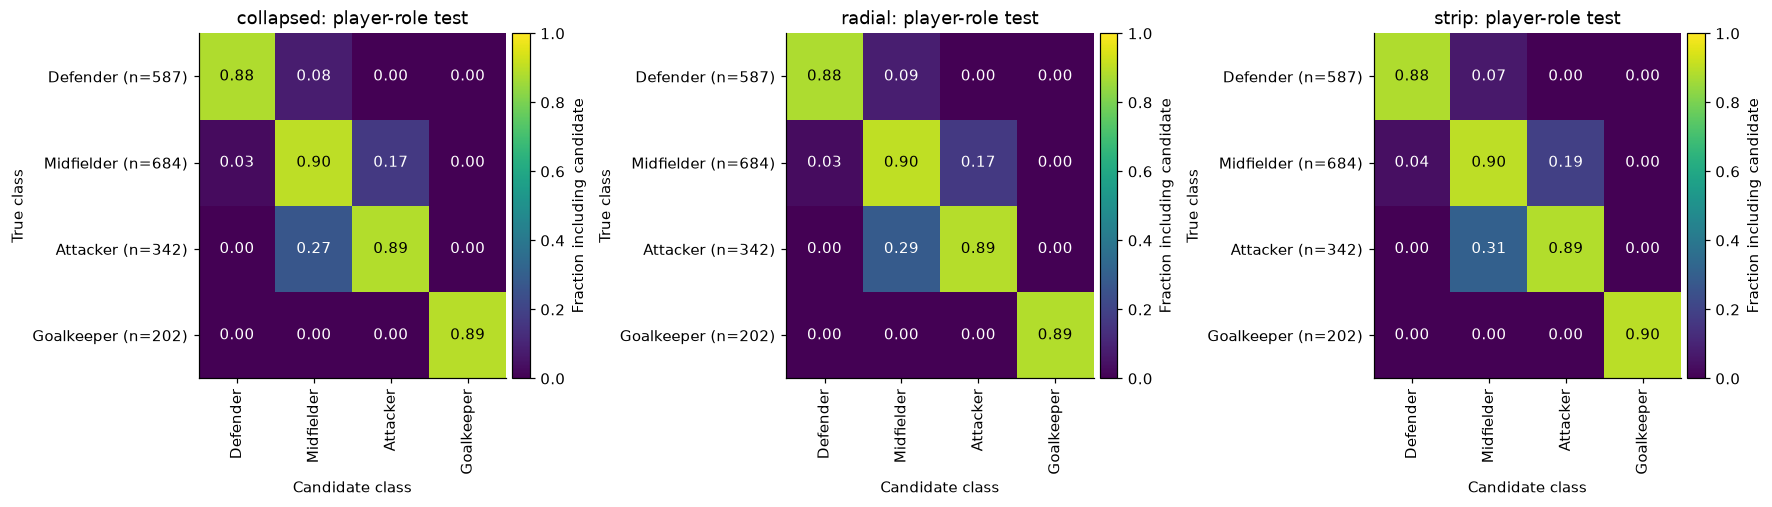

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for ax, (method, result) in zip(axes, predictions.items()):
    _, rates = plot_inclusion_heatmap(result['prediction_set'], test_truth.loc[result['ID']].tolist(),
                                      classes=CLASSES, ax=ax, title=f'{method}: player-role test', annotate=True)
fig.savefig(OUTPUT_DIR / 'inclusion_heatmaps.png', bbox_inches='tight')
plt.show()

## 16. Export the complete experiment

The notebook saves the source hash, partition IDs, validation results, score tables, test truth, prediction sets, metrics, and figures. Prediction sets are serialized as JSON arrays in CSV cells. Run metadata includes the actual alpha, model settings, package versions, and library source hashes, preventing results from different coverage targets from being silently compared.

The source CSV is cached separately. Generated outputs can always be recreated from this notebook; no output from another notebook is an input here.

In [29]:
conformal_scores.to_csv(OUTPUT_DIR / 'conformal_scores.csv', index=False)
test_scores.to_csv(OUTPUT_DIR / 'test_scores.csv', index=False)
test_truth.rename('label').to_csv(OUTPUT_DIR / 'test_truth.csv')
for method, table in evaluated.items():
    exported = table.copy()
    exported['prediction_set'] = exported['prediction_set'].map(json.dumps)
    exported.to_csv(OUTPUT_DIR / f'predictions_{method}.csv')
run_info = {'executed_at_utc': datetime.now(timezone.utc).isoformat(), 'seed': SEED,
            'alpha': ALPHA, 'shape_fraction': SHAPE_FRACTION, 'target_mapping': ROLE_GROUPS,
            'features': FEATURES, 'method_parameters': METHOD_PARAMS, 'retained_players': len(players),
            'partition_sizes': {name: len(frame) for name, frame in partitions.items()},
            'source_sha256': actual_sha256,
            'classifier_parameters': {name: repr(classifier) for name, classifier in classifiers.items()},
            'versions': {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
                         'sklearn': sklearn.__version__, 'matplotlib': matplotlib.__version__},
            'library_sha256': {str(path.relative_to(ROOT)): hashlib.sha256(path.read_bytes()).hexdigest()
                               for path in sorted((ROOT / 'conformal_envelopes').rglob('*.py'))},}
                               
(OUTPUT_DIR / 'run_info.json').write_text(json.dumps(run_info, indent=2), encoding='utf-8')
print('Saved experiment outputs to:', OUTPUT_DIR)

Saved experiment outputs to: /home/siddiqun/Bureau/Conformal Library/outputs/football_players


### Sources
- [Original FIFA 19 dataset: Karan Gadiya on Kaggle](https://www.kaggle.com/datasets/karangadiya/fifa19).
- [Public mirror with attribution to the original dataset](https://github.com/qualityjacks/Fifa19_Insights). The executable download cell gives the exact pinned file URL and checksum.
- Local `conformal_envelopes/model.py`, `calibration.py`, and `envelopes/`: the unchanged library implementation.